# Avito AntiBot — финальное решение

**Метрика:** Precision @ Recall ≥ 0.70  
**Валидация:** temporal walk-forward  
**Финальная архитектура:** rank blend четырёх моделей

| Модель | Признаки | Вес |
|---|---|---:|
| LightGBM | полный набор | 0.410 |
| CatBoost | полный набор | 0.130 |
| LightGBM | без TOP-5 по gain | 0.335 |
| CatBoost | без тех же TOP-5 | 0.125 |

Финальная temporal CV:

| Fold | Precision @ Recall ≥ 0.70 |
|---|---:|
| Fold 1 | 0.700000 |
| Fold 2 | 0.794286 |
| Fold 3 | 0.823944 |

Признаки строятся только по событиям внутри собственного 24-часового observation window.

## 1. Подготовка окружения

In [1]:
!pip install -q lightgbm catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.3 MB/s eta 0:00:00


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import lightgbm as lgb

from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from scipy.stats import rankdata

from metric import precision_at_recall

RANDOM_STATE = 0

train = pd.read_csv('data/train.csv', parse_dates=['cookie_created_at', 'window_start_ts', 'window_end_ts'])

test = pd.read_csv(
    'data/test.csv',
    parse_dates=['cookie_created_at', 'window_start_ts', 'window_end_ts'],
)

events = pd.read_csv(
    'data/events.csv.gz',
    parse_dates=['event_ts'],
)

print('train:', train.shape)
print('test:', test.shape)
print('events:', events.shape)
print('bot rate:', round(train['target'].mean(), 4))


train: (11091, 5)
test: (4909, 4)
events: (328905, 14)
bot rate: 0.0811


## 2. Анализ данных

Перед генерацией признаков отдельно исследовались основные поведенческие направления: временная динамика действий, структура просмотров и поиска, `user_agent`, а также геометрия движения указателя (`mouse / pointer shape`).

Отдельно от поиска сигнала выполнялась техническая проверка данных: соблюдение observation window, порядок событий и exact duplicates. Это не признаки поведения сами по себе, а обязательная подготовка данных перед построением признаков и валидацией.

Анализ ниже показывает, какие различия между human и bot удалось найти и какие из них затем использовались в финальном наборе признаков.


### 2.1. Размер данных, баланс классов и временная структура

В train **11 091 cookie**, из них **899 положительного класса** — около **8.11%**. Test содержит **4 909 cookie**.

Train расположен во времени с **6 по 19 апреля 2026**, test — с **20 по 26 апреля 2026**. Поэтому случайный split здесь не подходит: качество оценивается на последовательных временных фолдах, чтобы validation имитировал будущий период.

In [4]:
dataset_overview = pd.DataFrame({
    'train': [
        len(train),
        train['window_start_ts'].min(),
        train['window_start_ts'].max(),
        int(train['target'].sum()),
        float(train['target'].mean()),
    ],
    'test': [
        len(test),
        test['window_start_ts'].min(),
        test['window_start_ts'].max(),
        np.nan,
        np.nan,
    ],
}, index=[
    'cookies',
    'first_window',
    'last_window',
    'positive_cookies',
    'positive_rate',
])

display(dataset_overview)

,train,test
cookies,11091,4909
first_window,2026-04-06 00:00:00,2026-04-20 00:00:00
last_window,2026-04-19 00:00:00,2026-04-26 00:00:00
positive_cookies,899,NaN
positive_rate,0.081057,NaN


### 2.2. Observation window и exact duplicates

Перед анализом поведения все события ограничиваются собственным окном наблюдения:

`window_start_ts <= event_ts < window_end_ts`.

Для train-cookie в исходном event log было **239 215 событий**, из которых **198 436** находились внутри разрешённого окна. **40 779 событий** лежали после `window_end_ts` и были исключены до расчёта любых признаков.

Внутри корректного train-window найдено **2 952 exact duplicates** у **2 360 cookie**. Дубли сами по себе могут быть полезным техническим сигналом, поэтому их количество и доля сохраняются как отдельные признаки. Но перед расчётом временных интервалов, переходов и последовательностей exact duplicates удаляются, чтобы не создавать искусственные интервалы `gap = 0`.


In [5]:
def events_in_window(events, meta):
    merged = events.merge(
        meta[['cookie_id', 'window_start_ts', 'window_end_ts']],
        on='cookie_id',
        how='inner',
        validate='many_to_one',
    )

    inside = (
        merged['event_ts'].ge(merged['window_start_ts'])
        & merged['event_ts'].lt(merged['window_end_ts'])
    )

    return merged.loc[inside].copy().reset_index(drop=True)


ev_tr = events_in_window(events, train)
ev_te = events_in_window(events, test)

EVENT_COLUMNS = list(events.columns)

def event_integrity_row(events, meta, filtered, split):
    merged = events.merge(
        meta[['cookie_id', 'window_start_ts', 'window_end_ts']],
        on='cookie_id',
        how='inner',
        validate='many_to_one',
    )

    inside = (
        merged['event_ts'].ge(merged['window_start_ts'])
        & merged['event_ts'].lt(merged['window_end_ts'])
    )

    return {
        'split': split,
        'events_total_for_split_cookies': len(merged),
        'events_in_window': int(inside.sum()),
        'events_outside_window': int((~inside).sum()),
        'exact_duplicates_in_window': int(
            filtered.duplicated(subset=EVENT_COLUMNS).sum()
        ),
    }


integrity = pd.DataFrame([
    event_integrity_row(events, train, ev_tr, 'train'),
    event_integrity_row(events, test, ev_te, 'test'),
])

display(integrity)

print(
    'train cookies with exact duplicates:',
    ev_tr.loc[
        ev_tr.duplicated(subset=EVENT_COLUMNS, keep=False),
        'cookie_id'
    ].nunique()
)

assert len(ev_tr) == 198436
assert len(ev_te) == 89690
assert ev_tr.duplicated(subset=EVENT_COLUMNS).sum() == 2952
assert ev_te.duplicated(subset=EVENT_COLUMNS).sum() == 1341


,split,events_total_for_split_cookies,events_in_window,events_outside_window,exact_duplicates_in_window
0,train,239215,198436,40779,2952
1,test,89690,89690,0,1341


train cookies with exact duplicates: 2360


### 2.3. Временное поведение: bot действует плотнее и регулярнее

После удаления exact duplicates события сортировались по `cookie_id, event_ts`, после чего анализировались межсобытийные интервалы.

На уровне медиан bot-cookie имеют больше событий и заметно более короткие gaps:

| Признак | Human median | Bot median |
|---|---:|---:|
| `n_events` | 12 | 20 |
| `gap_median` | 60.5 s | 25.0 s |
| `gap_q75` | 128.0 s | 42.4 s |
| `gap_q90` | 1619.0 s | 129.7 s |
| `gap_share_lt_30s` | 0.250 | 0.533 |
| `gap_share_lt_60s` | 0.444 | 0.786 |
| `events_per_active_minute` | 0.099 | 0.148 |
| `mean_events_per_active_minute` | 1.333 | 1.947 |
| `max_events_per_minute` | 2 | 4 |

Важно, что эффект не объясняется только большим числом событий. После matching bot/human по дню и одинаковому `n_events` удалось сопоставить **805 из 899** bot-cookie. В matched-выборке `gap_median` остался **28 s у bot против 55 s у human**, а `mean_events_per_active_minute` — **1.82 против 1.36**.

Похожий эффект сохраняется и внутри одинаковых переходов:

| Transition | Human median gap | Bot median gap |
|---|---:|---:|
| `search_results_view → item_view` | 46 s | 12 s |
| `item_view → item_view` | 46 s | 12 s |
| `search_results_view → search_results_view` | 47 s | 13 s |
| `item_view → search_results_view` | 47 s | 13 s |
| `item_view → photo_swipe` | 50 s | 16 s |

Это стало основанием для gap-квантилей, долей коротких/длинных интервалов, activity density, burstiness и transition-gap признаков.

In [6]:
ev_seq = (
    ev_tr
    .drop_duplicates(subset=EVENT_COLUMNS)
    .sort_values(['cookie_id', 'event_ts'], kind='mergesort')
    .copy()
)

ev_seq['gap_sec'] = (
    ev_seq.groupby('cookie_id')['event_ts']
    .diff()
    .dt.total_seconds()
)

g = ev_seq.groupby('cookie_id', sort=False)

temporal_eda = pd.DataFrame(
    index=pd.Index(train['cookie_id'], name='cookie_id')
)

temporal_eda['n_events'] = g.size()
temporal_eda['gap_median'] = g['gap_sec'].median()
temporal_eda['gap_q75'] = g['gap_sec'].quantile(0.75)
temporal_eda['gap_q90'] = g['gap_sec'].quantile(0.90)

temporal_eda['gap_share_lt_30s'] = (
    ev_seq['gap_sec'].lt(30)
    .groupby(ev_seq['cookie_id'])
    .mean()
)

temporal_eda['gap_share_lt_60s'] = (
    ev_seq['gap_sec'].lt(60)
    .groupby(ev_seq['cookie_id'])
    .mean()
)

first_ts = g['event_ts'].min()
last_ts = g['event_ts'].max()

temporal_eda['active_span_sec'] = (
    last_ts - first_ts
).dt.total_seconds()

temporal_eda['events_per_active_minute'] = (
    temporal_eda['n_events']
    / (temporal_eda['active_span_sec'] / 60).clip(lower=1)
)

ev_seq['event_minute'] = ev_seq['event_ts'].dt.floor('min')

minute_counts = (
    ev_seq.groupby(['cookie_id', 'event_minute'])
    .size()
)

temporal_eda['mean_events_per_active_minute'] = (
    minute_counts.groupby(level=0).mean()
)

temporal_eda['max_events_per_minute'] = (
    minute_counts.groupby(level=0).max()
)

temporal_eda = (
    temporal_eda
    .join(train.set_index('cookie_id')['target'])
    .reset_index()
)

display(
    temporal_eda
    .groupby('target')[
        [
            'n_events',
            'gap_median',
            'gap_q75',
            'gap_q90',
            'gap_share_lt_30s',
            'gap_share_lt_60s',
            'events_per_active_minute',
            'mean_events_per_active_minute',
            'max_events_per_minute',
        ]
    ]
    .median()
    .T
    .rename(columns={0: 'human_median', 1: 'bot_median'})
)

target,human_median,bot_median
n_events,12.000000,20.000000
gap_median,60.500000,25.000000
gap_q75,128.000000,42.375000
gap_q90,1619.000000,129.700000
gap_share_lt_30s,0.250000,0.533333
gap_share_lt_60s,0.444444,0.785714
events_per_active_minute,0.098818,0.148423
mean_events_per_active_minute,1.333333,1.947368
max_events_per_minute,2.000000,4.000000


### 2.4. Разнообразие поведения, повторяемость и pagination

Отдельный анализ показал, что важен не только темп действий, но и **структура того, что cookie просматривает**.

Bot-cookie в среднем сильнее концентрируются внутри категорий, чаще повторяют поисковые запросы и глубже проходят выдачу:

| Признак | Human median | Bot median |
|---|---:|---:|
| `category_repeat_ratio` | 0.800 | 0.903 |
| `category_top1_share` | 0.688 | 0.857 |
| `category_entropy_norm` | 0.802 | 0.548 |
| `query_unique_ratio` | 1.000 | 0.667 |
| `query_repeat_ratio` | 0.000 | 0.333 |
| `page_median` | 2 | 3 |
| `page_max` | 4 | 7 |
| `page_ge5_share` | 0.000 | 0.222 |

Из большого diversity-блока в финальном решении особенно полезными оказались глубина pagination и поведение по объявлениям. В частности, `page_ge5_share`, `mean_max_page_per_query` и `mean_actions_per_item` были сохранены после последовательной проверки на temporal validation.

In [7]:
def compact_behavior_eda(ev, meta):
    e = (
        ev.drop_duplicates(subset=EVENT_COLUMNS)
        .sort_values(['cookie_id', 'event_ts'], kind='mergesort')
        .copy()
    )

    out = pd.DataFrame(index=pd.Index(meta['cookie_id'], name='cookie_id'))

    category = e[e['item_category'].notna()].copy()
    if len(category):
        cg = category.groupby('cookie_id')['item_category']
        count = cg.count()
        nunique = cg.nunique()
        out['category_repeat_ratio'] = 1 - nunique / count

        def top_share(s):
            return s.value_counts(normalize=True).iloc[0]

        out['category_top1_share'] = cg.apply(top_share)

    search = e[
        e['event_name'].eq('search_results_view')
        & e['search_query'].notna()
    ].copy()

    if len(search):
        sg = search.groupby('cookie_id')['search_query']
        count = sg.count()
        nunique = sg.nunique()
        out['query_unique_ratio'] = nunique / count
        out['query_repeat_ratio'] = 1 - nunique / count

    page = e[
        e['event_name'].eq('search_results_view')
        & e['search_page'].notna()
    ].copy()

    page['search_page'] = pd.to_numeric(
        page['search_page'],
        errors='coerce'
    )
    page = page[page['search_page'].notna()]

    if len(page):
        pg = page.groupby('cookie_id')['search_page']
        out['page_median'] = pg.median()
        out['page_max'] = pg.max()
        out['page_ge5_share'] = (
            page['search_page'].ge(5)
            .groupby(page['cookie_id'])
            .mean()
        )

    return (
        out
        .join(meta.set_index('cookie_id')['target'])
        .reset_index()
    )


behavior_eda = compact_behavior_eda(ev_tr, train)

display(
    behavior_eda
    .groupby('target')[
        [
            'category_repeat_ratio',
            'category_top1_share',
            'query_unique_ratio',
            'query_repeat_ratio',
            'page_median',
            'page_max',
            'page_ge5_share',
        ]
    ]
    .median()
    .T
    .rename(columns={0: 'human_median', 1: 'bot_median'})
)

target,human_median,bot_median
category_repeat_ratio,0.8000,0.903226
category_top1_share,0.6875,0.857143
query_unique_ratio,1.0000,0.666667
query_repeat_ratio,0.0000,0.333333
page_median,2.0000,3.000000
page_max,4.0000,7.000000
page_ge5_share,0.0000,0.222222


### 2.5. `user_agent`: полезнее семантика, чем запоминание полной строки

В train и test присутствуют одни и те же **148 exact user-agent строк**, но их частоты заметно меняются со временем.

Total Variation Distance для распределения точных UA составляет **0.1194**, тогда как после агрегации до устойчивых семейств (`chrome`, `firefox`, `yabrowser`, `avito_app`, `headless`, `script`, ...) — только **0.0235**. Поэтому модель получает не только exact-UA diversity, но и семантические признаки семейства, ОС, mobile, headless/script и смены UA внутри cookie.

Automation-маркеры действительно несут сигнал, но не покрывают весь положительный класс:

| UA-группа | Cookie | Bot rate | Доля всех bot |
|---|---:|---:|---:|
| `headless` | 286 | 0.262 | 0.083 |
| `script` | 173 | 0.225 | 0.043 |
| `avito_app` | 2141 | 0.092 | 0.219 |
| `mobile` | 5174 | 0.060 | 0.346 |

Поэтому `HeadlessChrome` или script-UA нельзя использовать как жёсткое правило — это только один из источников сигнала.

In [8]:
SCRIPT_PATTERNS_EDA = (
    'scrapy/',
    'curl/',
    'python-urllib',
    'python-requests',
    'node-fetch',
    'go-http-client',
)

def ua_family_for_eda(s):
    s = '' if pd.isna(s) else str(s)
    low = s.lower()

    if any(p in low for p in SCRIPT_PATTERNS_EDA):
        return 'script'
    if 'headlesschrome' in low:
        return 'headless'
    if 'yabrowser' in low:
        return 'yabrowser'
    if 'firefox' in low:
        return 'firefox'
    if s.startswith('Avito/'):
        return 'avito_app'
    if 'chrome' in low:
        return 'chrome'
    if 'safari' in low:
        return 'safari'
    return 'other'


ua_tr = ev_tr[['cookie_id', 'user_agent']].copy()
ua_te = ev_te[['cookie_id', 'user_agent']].copy()

ua_tr['ua_family'] = ua_tr['user_agent'].map(ua_family_for_eda)
ua_te['ua_family'] = ua_te['user_agent'].map(ua_family_for_eda)

def total_variation(train_s, test_s):
    a = train_s.value_counts(normalize=True).rename('train')
    b = test_s.value_counts(normalize=True).rename('test')
    joined = pd.concat([a, b], axis=1).fillna(0)
    return 0.5 * (joined['train'] - joined['test']).abs().sum()

print('unique exact UA train:', ua_tr['user_agent'].nunique())
print('unique exact UA test :', ua_te['user_agent'].nunique())
print(
    'exact UA TV:',
    round(total_variation(ua_tr['user_agent'], ua_te['user_agent']), 4)
)
print(
    'UA family TV:',
    round(total_variation(ua_tr['ua_family'], ua_te['ua_family']), 4)
)

unique exact UA train: 148
unique exact UA test : 148
exact UA TV: 0.1194
UA family TV: 0.0225


### 2.6. Mouse / pointer shape

Координаты указателя анализировались только для web-событий с одновременно заполненными `pointer_x` и `pointer_y`. Координаты нормализуются на условный размер экрана `1920 × 1080`; цель здесь не восстановить реальное разрешение устройства, а сравнивать **форму области движения** в единой шкале.

Сначала важен сам факт наличия pointer-событий. В train хотя бы один web-pointer есть у **36.8% human-cookie** и **27.9% bot-cookie**. При этом общий share cookie с web-pointer очень стабилен между train и test: **36.08% против 36.57%**.

Но основной сигнал появляется внутри cookie, где pointer действительно есть:

| Pointer feature, median | Human | Bot |
|---|---:|---:|
| `pointer_count_web` | 8 | 14 |
| `pointer_extent` | 0.403 | 0.213 |
| `pointer_area_proxy` | 0.077 | 0.019 |
| `pointer_axis_imbalance` | 0.161 | 0.554 |
| `pointer_center_dist_mean` | 0.384 | 0.328 |
| `pointer_center_dist_std` | 0.136 | 0.112 |
| `pointer_edge_share` | 0.000 | 0.048 |

В этих данных bot-cookie с pointer-событиями в среднем имеют **больше координатных событий, но меньшую покрываемую область**: ниже `extent` и `area_proxy`, выше дисбаланс по осям. Это похоже на более узкие или направленные траектории. `edge_share` также выше у bot-cookie.

Это не используется как правило `bot/human`: значения сильно пересекаются. Поэтому shape-метрики передаются модели как обычные числовые признаки и работают совместно с временным, UA и content-сигналом.

In [9]:
def pointer_shape_eda(ev, meta):
    platform = ev['platform'].astype(str).str.lower()

    pts = ev.loc[
        platform.eq('web')
        & ev['pointer_x'].notna()
        & ev['pointer_y'].notna(),
        ['cookie_id', 'pointer_x', 'pointer_y']
    ].copy()

    pts['x_scaled'] = pts['pointer_x'] / 1920.0
    pts['y_scaled'] = pts['pointer_y'] / 1080.0

    pts['center_dist'] = np.sqrt(
        (pts['x_scaled'] - 0.5) ** 2
        + (pts['y_scaled'] - 0.5) ** 2
    )

    g = pts.groupby('cookie_id')

    out = pd.DataFrame(
        index=pd.Index(meta['cookie_id'], name='cookie_id')
    )

    x_std = g['x_scaled'].std()
    y_std = g['y_scaled'].std()

    out['pointer_count_web'] = g.size()

    out['pointer_extent'] = np.sqrt(
        x_std ** 2 + y_std ** 2
    )

    out['pointer_area_proxy'] = (
        x_std * y_std
    )

    out['pointer_axis_imbalance'] = np.abs(
        np.log(
            (x_std + 1e-6)
            / (y_std + 1e-6)
        )
    )

    out['pointer_center_dist_mean'] = (
        g['center_dist'].mean()
    )

    out['pointer_center_dist_std'] = (
        g['center_dist'].std()
    )

    edge = (
        (pts['x_scaled'] <= 0.02)
        | (pts['x_scaled'] >= 0.98)
        | (pts['y_scaled'] <= 0.02)
        | (pts['y_scaled'] >= 0.98)
    )

    out['pointer_edge_share'] = (
        edge.groupby(pts['cookie_id']).mean()
    )

    out['has_pointer_web'] = (
        out['pointer_count_web'].fillna(0).gt(0).astype(int)
    )

    out = (
        out
        .replace([np.inf, -np.inf], np.nan)
        .fillna(0)
        .join(meta.set_index('cookie_id')['target'])
        .reset_index()
    )

    return out


pointer_eda = pointer_shape_eda(ev_tr, train)

presence = (
    pointer_eda
    .groupby('target')['has_pointer_web']
    .mean()
    .rename(index={0: 'human', 1: 'bot'})
)

print('share of cookies with web pointer:')
display(presence.to_frame('share'))

pointer_positive = pointer_eda[
    pointer_eda['has_pointer_web'].eq(1)
]

display(
    pointer_positive
    .groupby('target')[
        [
            'pointer_count_web',
            'pointer_extent',
            'pointer_area_proxy',
            'pointer_axis_imbalance',
            'pointer_center_dist_mean',
            'pointer_center_dist_std',
            'pointer_edge_share',
        ]
    ]
    .median()
    .T
    .rename(columns={0: 'human_median', 1: 'bot_median'})
)

share of cookies with web pointer:


,share
target,
human,0.368034
bot,0.279199


target,human_median,bot_median
pointer_count_web,8.000000,14.000000
pointer_extent,0.402532,0.212883
pointer_area_proxy,0.077423,0.019121
pointer_axis_imbalance,0.160819,0.553680
pointer_center_dist_mean,0.384454,0.327977
pointer_center_dist_std,0.136065,0.112244
pointer_edge_share,0.000000,0.047619


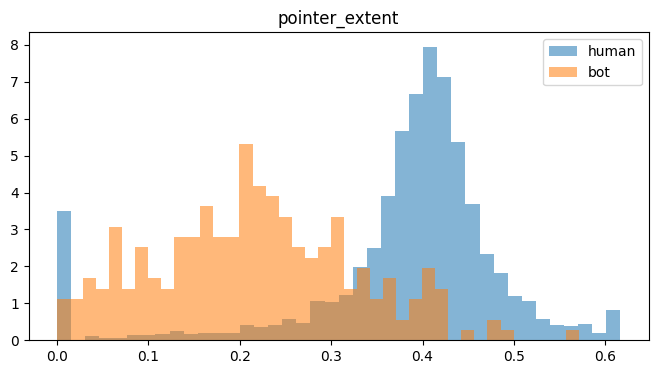

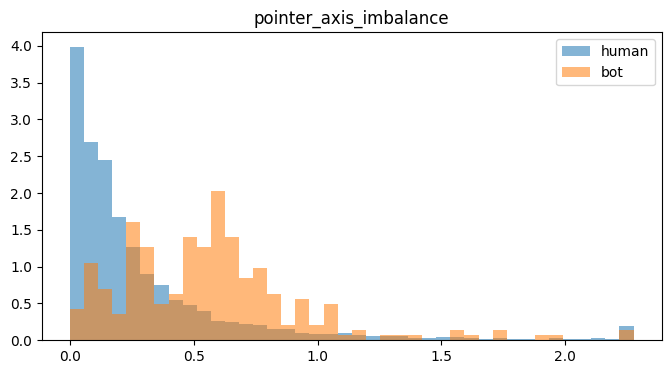

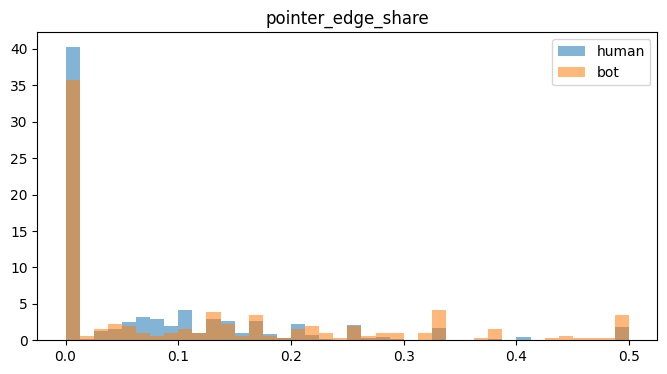

In [10]:
# Визуальная проверка наиболее интерпретируемых shape-признаков.

for feature in [
    'pointer_extent',
    'pointer_axis_imbalance',
    'pointer_edge_share',
]:
    plt.figure(figsize=(8, 4))

    human = pointer_positive.loc[
        pointer_positive['target'].eq(0),
        feature
    ]

    bot = pointer_positive.loc[
        pointer_positive['target'].eq(1),
        feature
    ]

    upper = pointer_positive[feature].quantile(0.99)

    plt.hist(
        human.clip(upper=upper),
        bins=40,
        density=True,
        alpha=0.55,
        label='human',
    )

    plt.hist(
        bot.clip(upper=upper),
        bins=40,
        density=True,
        alpha=0.55,
        label='bot',
    )

    plt.title(feature)
    plt.legend()
    plt.show()

### 2.7. Что из EDA перешло в признаки

После анализа финальный feature space был собран вокруг нескольких устойчивых групп:

- **activity / temporal:** количество событий, gap-квантили, доли коротких и длинных интервалов, active span, events-per-minute, burstiness, session и transition timing;
- **content / navigation:** diversity по item/category/query, pagination depth, `page_ge5_share`, `mean_max_page_per_query`, `mean_actions_per_item`;
- **user-agent:** семейство клиента, ОС, mobile, headless/script/app flags, версии и смена UA;
- **pointer:** наличие координат, количество/разброс перемещений и отдельный mouse-shape блок — extent, area, axis imbalance, расстояние от центра и edge share;
- **integrity:** число и доля exact duplicates.


## 3. История экспериментов

После EDA признаки добавлялись не все сразу. Каждый блок проверялся на temporal validation, а признаки, которые давали нестабильный или отрицательный эффект, удалялись.

Наиболее устойчивыми оказались temporal density, `mean_actions_per_item`, pagination и компактный pointer-shape блок. Расширенные pointer-признаки, дополнительные burst/session-варианты и слишком детальные diversity-метрики не давали стабильного прироста и в финальную версию не вошли.

Следующий этап — разнообразить не только признаки, но и сами модели. Для этого были обучены дополнительные LightGBM и CatBoost, которым намеренно скрывались пять наиболее важных признаков полного LightGBM. Это дало модели с отличающейся структурой ошибок и улучшило ансамбль.

### Эволюция ансамбля

| Эксперимент | Fold 1 | Fold 2 | Fold 3 | Weighted | Что получили |
|---|---:|---:|---:|---:|---|
| LGBM + CatBoost, rank `0.76 / 0.24` | 0.668246 | 0.769663 | 0.849624 | 0.785362 | базовый ансамбль |
| + LGBM без TOP-5, вес `0.275` | 0.681159 | 0.794286 | 0.825175 | 0.785561 | сильный рост Fold 1/2, снижение Fold 3 |
| Без CatBoost: full LGBM + no-TOP5 LGBM | 0.682927 | 0.778409 | 0.837037 | — | хуже по Fold 2, CatBoost оставлен |
| + LGBM без TOP-10, вес `0.025` | 0.686275 | 0.790960 | 0.826389 | 0.785966 | небольшой прирост, модель не оставлена |
| + CatBoost без TOP-5, вес `0.080` | 0.693069 | 0.792135 | 0.825175 | 0.787190 | лучше баланс и стабильность |
| Независимый подбор 4 весов `0.44 / 0.16 / 0.30 / 0.10` | 0.700000 | 0.791908 | 0.825175 | 0.788496 | сильная robust-конфигурация |
| Финальные веса `0.410 / 0.130 / 0.335 / 0.125` | **0.700000** | **0.794286** | **0.823944** | **0.788775** | выбранный финальный ансамбль |

Итоговая архитектура использует четыре модели: full LightGBM, full CatBoost и их версии без пяти наиболее важных для LightGBM признаков. Предсказания переводятся в ранги и затем смешиваются фиксированными весами.

## 4. Генерация признаков

In [11]:
# 1. Preprocessing / helpers

EVENT_COLUMNS = list(events.columns)

def prepare_sequence_events(ev):
    # Сначала exact deduplication по исходным полям события, затем стабильная сортировка.
    # Никогда не полагаемся на исходный порядок строк events.csv.gz.
    return ev.drop_duplicates(subset=EVENT_COLUMNS).sort_values(
        ['cookie_id', 'event_ts'],
        kind='mergesort'
    ).copy()

SCRIPT_PATTERNS = ('scrapy/', 'curl/', 'python-urllib', 'node-fetch', 'go-http-client')

def normalize_platform(x):
    if pd.isna(x):
        return 'unknown'
    x = str(x).strip().lower()
    if x in {'web', 'desktop'}:
        return 'web'
    if x == 'android':
        return 'android'
    if x in {'ios', 'iphone'}:
        return 'ios'
    return x

def enrich_event_level(ev):
    out = ev.copy()
    out['platform_norm'] = out['platform'].map(normalize_platform)
    ua = out['user_agent'].fillna('').astype(str)
    ua_lower = ua.str.lower()
    out['ua_is_headless'] = ua_lower.str.contains('headlesschrome', regex=False).astype('int8')
    out['ua_is_script'] = ua_lower.apply(lambda s: int(any((p in s for p in SCRIPT_PATTERNS)))).astype('int8')
    out['ua_is_avito_app'] = ua.str.startswith('Avito/').astype('int8')
    out['ua_is_mobile'] = (ua_lower.str.contains('mobile', regex=False) | ua_lower.str.contains('android', regex=False) | ua_lower.str.contains('iphone', regex=False)).astype('int8')
    out['ua_os_windows'] = ua_lower.str.contains('windows', regex=False).astype('int8')
    out['ua_os_android'] = ua_lower.str.contains('android', regex=False).astype('int8')
    out['ua_os_ios'] = (ua_lower.str.contains('iphone', regex=False) | ua_lower.str.contains('ios', regex=False)).astype('int8')
    out['ua_os_mac'] = (ua_lower.str.contains('macintosh', regex=False) & ~out['ua_os_ios'].astype(bool)).astype('int8')
    out['ua_os_linux'] = (ua_lower.str.contains('linux', regex=False) & ~out['ua_os_android'].astype(bool)).astype('int8')
    out['ua_os'] = np.select([out['ua_os_android'].astype(bool), out['ua_os_ios'].astype(bool), out['ua_os_windows'].astype(bool), out['ua_os_mac'].astype(bool), out['ua_os_linux'].astype(bool)], ['android', 'ios', 'windows', 'macos', 'linux'], default='other')
    out['ua_family'] = np.select([out['ua_is_script'].astype(bool), out['ua_is_headless'].astype(bool), ua_lower.str.contains('yabrowser', regex=False), ua_lower.str.contains('firefox', regex=False), out['ua_is_avito_app'].astype(bool), ua_lower.str.contains('chrome', regex=False), ua_lower.str.contains('safari', regex=False)], ['script', 'headless', 'yabrowser', 'firefox', 'avito_app', 'chrome', 'safari'], default='other')
    version = ua.str.extract('HeadlessChrome/(\\d+)', expand=False).combine_first(ua.str.extract('YaBrowser/(\\d+)', expand=False)).combine_first(ua.str.extract('Firefox/(\\d+)', expand=False)).combine_first(ua.str.extract('Chrome/(\\d+)', expand=False)).combine_first(ua.str.extract('Avito/(\\d+)', expand=False)).combine_first(ua.str.extract('Version/(\\d+)', expand=False))
    out['ua_major_version'] = pd.to_numeric(version, errors='coerce')
    out['ua_length'] = ua.str.len().astype('int16')
    return out
ev_tr = enrich_event_level(ev_tr)
ev_te = enrich_event_level(ev_te)
EVENT_TYPES = sorted(pd.concat([ev_tr['event_name'], ev_te['event_name']], ignore_index=True).dropna().unique())
PLATFORM_TYPES = ['web', 'android', 'ios', 'unknown']
UA_FAMILIES = ['headless', 'yabrowser', 'firefox', 'chrome', 'safari', 'avito_app', 'script', 'other']
IMPORTANT_TEMPORAL_TRANSITIONS = [('search_results_view', 'item_view'), ('search_results_view', 'search_results_view'), ('item_view', 'item_view'), ('item_view', 'search_results_view'), ('item_view', 'photo_swipe'), ('item_view', 'seller_page_view'), ('seller_page_view', 'item_view')]

def safe_div(num, den):
    den = den.replace(0, np.nan)
    return num / den

def entropy_from_counts(frame):
    arr = frame.to_numpy(dtype=float)
    row_sum = arr.sum(axis=1, keepdims=True)
    p = np.divide(arr, row_sum, out=np.zeros_like(arr), where=row_sum != 0)
    logp = np.zeros_like(p)
    mask = p > 0
    logp[mask] = np.log(p[mask])
    return -(p * logp).sum(axis=1)

In [12]:
# 2. Basic features

def generate_basic_features(ev, meta):
    base = pd.DataFrame(index=pd.Index(meta['cookie_id'], name='cookie_id'))
    raw = ev.copy()
    raw['is_duplicate'] = raw.duplicated(subset=EVENT_COLUMNS, keep='first')
    g_raw = raw.groupby('cookie_id', sort=False)
    base['n_events_raw'] = g_raw.size()
    base['duplicate_count'] = g_raw['is_duplicate'].sum()
    base['duplicate_ratio'] = safe_div(base['duplicate_count'], base['n_events_raw'])
    e = prepare_sequence_events(raw)
    g = e.groupby('cookie_id', sort=False)
    base['n_events'] = g.size()
    base['event_type_nunique'] = g['event_name'].nunique()
    base['item_nunique'] = g['item_id'].nunique()
    base['category_nunique'] = g['item_category'].nunique()
    base['location_nunique'] = g['item_location'].nunique()
    base['query_nunique'] = g['search_query'].nunique()
    base['search_page_nunique'] = g['search_page'].nunique()
    base['ua_nunique'] = g['user_agent'].nunique()
    base['ua_family_nunique'] = g['ua_family'].nunique()
    base['platform_nunique'] = g['platform_norm'].nunique()
    item_views = e['event_name'].eq('item_view').groupby(e['cookie_id']).sum()
    search_views = e['event_name'].eq('search_results_view').groupby(e['cookie_id']).sum()
    base['unique_items_per_item_event'] = safe_div(base['item_nunique'], item_views)
    base['unique_queries_per_search_event'] = safe_div(base['query_nunique'], search_views)
    base['unique_categories_per_event'] = safe_div(base['category_nunique'], base['n_events'])
    base['unique_locations_per_event'] = safe_div(base['location_nunique'], base['n_events'])
    event_counts = pd.crosstab(e['cookie_id'], e['event_name'])
    event_counts = event_counts.reindex(columns=EVENT_TYPES, fill_value=0)
    event_counts.columns = [f'event_count__{c}' for c in event_counts.columns]
    base = base.join(event_counts, how='left')
    for event_name in EVENT_TYPES:
        c = f'event_count__{event_name}'
        base[f'event_ratio__{event_name}'] = safe_div(base[c], base['n_events'])
    count_cols = [f'event_count__{c}' for c in EVENT_TYPES]
    base['event_type_entropy'] = entropy_from_counts(base[count_cols].fillna(0))
    search = e[e['event_name'].eq('search_results_view')].copy()
    if len(search):
        sg = search.groupby('cookie_id')
        base['search_page_mean'] = sg['search_page'].mean()
        base['search_page_max'] = sg['search_page'].max()
        base['search_page_std'] = sg['search_page'].std()
        base['search_query_nonnull_count'] = sg['search_query'].count()
        base['search_query_repeat_ratio'] = 1 - safe_div(sg['search_query'].nunique(), sg['search_query'].count())
    platform_counts = pd.crosstab(e['cookie_id'], e['platform_norm'])
    for p in PLATFORM_TYPES:
        if p not in platform_counts.columns:
            platform_counts[p] = 0
        base[f'platform_ratio__{p}'] = safe_div(platform_counts[p], base['n_events'])
    ua_counts = pd.crosstab(e['cookie_id'], e['ua_family'])
    for fam in UA_FAMILIES:
        if fam not in ua_counts.columns:
            ua_counts[fam] = 0
        base[f'ua_ratio__{fam}'] = safe_div(ua_counts[fam], base['n_events'])
    ua_flag_cols = ['ua_is_headless', 'ua_is_script', 'ua_is_avito_app', 'ua_os_windows', 'ua_os_android', 'ua_os_ios', 'ua_os_mac', 'ua_os_linux']
    for c in ua_flag_cols:
        base[f'{c}_ratio'] = g[c].mean()
    base['pointer_present_ratio'] = (e['pointer_x'].notna() & e['pointer_y'].notna()).groupby(e['cookie_id']).mean()
    base['seller_type_present_ratio'] = e['seller_type'].notna().groupby(e['cookie_id']).mean()
    base['category_present_ratio'] = e['item_category'].notna().groupby(e['cookie_id']).mean()
    base['location_present_ratio'] = e['item_location'].notna().groupby(e['cookie_id']).mean()
    ptr = e[e['pointer_x'].notna() & e['pointer_y'].notna()].copy()
    if len(ptr):
        pg = ptr.groupby('cookie_id')
        base['pointer_count'] = pg.size()
        base['pointer_x_nunique'] = pg['pointer_x'].nunique()
        base['pointer_y_nunique'] = pg['pointer_y'].nunique()
        base['pointer_x_std'] = pg['pointer_x'].std()
        base['pointer_y_std'] = pg['pointer_y'].std()
        base['pointer_x_range'] = pg['pointer_x'].max() - pg['pointer_x'].min()
        base['pointer_y_range'] = pg['pointer_y'].max() - pg['pointer_y'].min()
        ptr['pointer_dx'] = ptr.groupby('cookie_id')['pointer_x'].diff()
        ptr['pointer_dy'] = ptr.groupby('cookie_id')['pointer_y'].diff()
        ptr['pointer_move'] = np.sqrt(ptr['pointer_dx'] ** 2 + ptr['pointer_dy'] ** 2)
        pm = ptr.groupby('cookie_id')['pointer_move'].agg(['mean', 'median', 'max'])
        pm.columns = ['pointer_move_mean', 'pointer_move_median', 'pointer_move_max']
        base = base.join(pm, how='left')
    e['prev_event_name'] = e.groupby('cookie_id')['event_name'].shift()
    trans = e.loc[e['prev_event_name'].notna(), ['cookie_id', 'prev_event_name', 'event_name']].copy()
    trans['transition'] = trans['prev_event_name'] + '__to__' + trans['event_name']
    if len(trans):
        trans_counts = pd.crosstab(trans['cookie_id'], trans['transition'])
        trans_counts.columns = [f'transition_count__{c}' for c in trans_counts.columns]
        base = base.join(trans_counts, how='left')
        transition_cols = [c for c in base.columns if c.startswith('transition_count__')]
        transition_total = base[transition_cols].sum(axis=1)
        base['transition_entropy'] = entropy_from_counts(base[transition_cols].fillna(0))
        for c in transition_cols:
            ratio_name = c.replace('transition_count__', 'transition_ratio__')
            base[ratio_name] = safe_div(base[c], transition_total)
    meta_idx = meta.set_index('cookie_id')
    base['cookie_age_days'] = (meta_idx['window_start_ts'] - meta_idx['cookie_created_at']).dt.total_seconds() / 86400

        # --------------------------------------------------------
    # Remove redundant / noisy features
    # --------------------------------------------------------

    drop_cols = [
        # raw activity duplicates
        'n_events_raw',
        'duplicate_count',

        # diversity already represented better elsewhere
        'event_type_nunique',
        'query_nunique',
        'platform_nunique',
        'ua_nunique',
        'ua_family_nunique',

        # query duplication
        'unique_queries_per_search_event',
        'search_query_nonnull_count',

        # UA duplicates
        'ua_is_headless_ratio',
        'ua_is_script_ratio',
        'ua_is_avito_app_ratio',

        # weak OS technical signals
        'ua_os_windows_ratio',
        'ua_os_android_ratio',
        'ua_os_ios_ratio',
        'ua_os_mac_ratio',
        'ua_os_linux_ratio',

        # weak missingness
        'category_present_ratio',
        'location_present_ratio',
    ]

    # event_count дублирует event_ratio + n_events
    drop_cols += [
        c for c in base.columns
        if c.startswith('event_count__')
    ]

    # transition_count дублирует transition_ratio + n transitions
    drop_cols += [
        c for c in base.columns
        if c.startswith('transition_count__')
    ]

    base = base.drop(
        columns=drop_cols,
        errors='ignore'
    )

    base = base.replace([np.inf, -np.inf], np.nan).fillna(0)
    return base.reset_index()

In [13]:
def generate_temporal_features(ev, meta):
    temporal = pd.DataFrame(index=pd.Index(meta['cookie_id'], name='cookie_id'))
    e = prepare_sequence_events(ev)

    g = e.groupby('cookie_id', sort=False)
    e['gap_sec'] = g['event_ts'].diff().dt.total_seconds()

    gap = e[e['gap_sec'].notna()].copy()
    gg = gap.groupby('cookie_id')

    temporal['gap_mean_sec'] = gg['gap_sec'].mean()
    temporal['gap_std_sec'] = gg['gap_sec'].std()
    temporal['gap_min_sec'] = gg['gap_sec'].min()
    temporal['gap_max_sec'] = gg['gap_sec'].max()
    temporal['gap_median_sec'] = gg['gap_sec'].median()

    for q in [0.1, 0.25, 0.75, 0.9]:
        temporal[f'gap_q{int(q * 100):02d}_sec'] = gg['gap_sec'].quantile(q)

    for threshold in [1, 5, 10, 30, 60]:
        temporal[f'gap_share_lt_{threshold}s'] = gap['gap_sec'].lt(threshold).groupby(gap['cookie_id']).mean()

    for threshold in [300, 600, 1800]:
        temporal[f'gap_share_gt_{threshold}s'] = gap['gap_sec'].gt(threshold).groupby(gap['cookie_id']).mean()

    g = e.groupby('cookie_id', sort=False)

    first_ts = g['event_ts'].min()
    last_ts = g['event_ts'].max()

    temporal['active_span_sec'] = (last_ts - first_ts).dt.total_seconds()

    n_events = g.size()
    temporal['events_per_active_minute'] = n_events / (temporal['active_span_sec'] / 60).clip(lower=1)

    e['event_hour'] = e['event_ts'].dt.hour
    e['event_minute'] = e['event_ts'].dt.floor('min')

    temporal['active_hour_nunique'] = e.groupby('cookie_id')['event_hour'].nunique()
    temporal['active_minute_nunique'] = e.groupby('cookie_id')['event_minute'].nunique()

    minute_counts = e.groupby(['cookie_id', 'event_minute']).size()
    minute_stats = minute_counts.groupby(level=0).agg(['max', 'mean'])
    minute_stats.columns = ['max_events_per_minute', 'mean_events_per_active_minute']
    temporal = temporal.join(minute_stats, how='left')

    e['new_session'] = e['gap_sec'].isna() | e['gap_sec'].gt(1800)
    e['session_id'] = e.groupby('cookie_id')['new_session'].cumsum()

    session_sizes = e.groupby(['cookie_id', 'session_id']).size()
    session_stats = session_sizes.groupby(level=0).agg(['count', 'mean', 'max'])
    session_stats.columns = ['session_count', 'session_size_mean', 'session_size_max']
    temporal = temporal.join(session_stats, how='left')

    def gap_unique_ratio(x):
        x = x.dropna().round()
        if len(x) == 0:
            return np.nan
        return x.nunique() / len(x)

    def gap_mode_share(x):
        x = x.dropna().round()
        if len(x) == 0:
            return np.nan
        return x.value_counts(normalize=True).iloc[0]

    temporal['gap_unique_ratio'] = g['gap_sec'].apply(gap_unique_ratio)
    temporal['gap_mode_share'] = g['gap_sec'].apply(gap_mode_share)

    gap_mean = g['gap_sec'].mean()
    gap_std = g['gap_sec'].std()

    temporal['gap_cv'] = gap_std / gap_mean.replace(0, np.nan)
    temporal['burstiness'] = (gap_std - gap_mean) / (gap_std + gap_mean).replace(0, np.nan)

    e['prev_gap_sec'] = e.groupby('cookie_id')['gap_sec'].shift()
    e['gap_change_abs'] = (e['gap_sec'] - e['prev_gap_sec']).abs()

    gap_change = e.groupby('cookie_id')['gap_change_abs']
    temporal['gap_change_mean'] = gap_change.mean()
    temporal['gap_change_median'] = gap_change.median()

    e['fast_gap'] = e['gap_sec'].lt(30)
    prev_fast = e.groupby('cookie_id')['fast_gap'].shift().fillna(False).astype(bool)
    e['fast_burst_start'] = e['fast_gap'] & ~prev_fast
    temporal['fast_burst_count'] = e.groupby('cookie_id')['fast_burst_start'].sum()

    e['prev_event_name'] = e.groupby('cookie_id')['event_name'].shift()

    for prev_event, current_event in IMPORTANT_TEMPORAL_TRANSITIONS:
        mask = (
            e['prev_event_name'].eq(prev_event)
            & e['event_name'].eq(current_event)
            & e['gap_sec'].notna()
        )

        tr = e.loc[mask, ['cookie_id', 'gap_sec']]

        if len(tr) == 0:
            continue

        tg = tr.groupby('cookie_id')['gap_sec']
        prefix = f'transition_gap__{prev_event}__to__{current_event}'

        temporal[f'{prefix}__mean'] = tg.mean()
        temporal[f'{prefix}__median'] = tg.median()
        temporal[f'{prefix}__q25'] = tg.quantile(0.25)
        temporal[f'{prefix}__q75'] = tg.quantile(0.75)

    temporal = temporal.replace([np.inf, -np.inf], np.nan).fillna(0)

    return temporal.reset_index()

In [14]:
# 4. User-agent + full generator

def generate_user_agent_features(ev, meta):
    features = pd.DataFrame(index=pd.Index(meta['cookie_id'], name='cookie_id'))

    e = prepare_sequence_events(ev)
    g = e.groupby('cookie_id', sort=False)

    # Доля mobile-событий
    features['ua_is_mobile_ratio'] = g['ua_is_mobile'].mean()

    # Сколько разных major version встретилось внутри cookie
    features['ua_major_version_nunique'] = g['ua_major_version'].nunique()

    # Предыдущий UA / UA-family
    prev_ua = g['user_agent'].shift()
    prev_family = g['ua_family'].shift()

    # Менялся ли exact UA между соседними событиями
    e['ua_changed'] = prev_ua.notna() & e['user_agent'].ne(prev_ua)

    # Менялось ли семейство клиента
    e['ua_family_changed'] = prev_family.notna() & e['ua_family'].ne(prev_family)

    # Число возможных переходов между событиями
    n_events = g.size()
    transition_count = (n_events - 1).clip(lower=1)

    features['ua_change_ratio'] = e.groupby('cookie_id')['ua_changed'].sum() / transition_count
    features['ua_family_change_ratio'] = e.groupby('cookie_id')['ua_family_changed'].sum() / transition_count

    return features.replace([np.inf, -np.inf], np.nan).fillna(0).reset_index()

In [15]:
def generate_diversity_features(ev, meta):
    features = pd.DataFrame(index=pd.Index(meta['cookie_id'], name='cookie_id'))

    e = prepare_sequence_events(ev)

    # ========================================================
    # 2. Search
    # ========================================================

    search = e[e['event_name'].eq('search_results_view')].copy()

    # ========================================================
    # 3. Насколько часто cookie уходит глубоко в выдачу
    # ========================================================

    page = search[search['search_page'].notna()].copy()
    page['search_page'] = pd.to_numeric(page['search_page'], errors='coerce')
    page = page[page['search_page'].notna()].copy()

    if len(page):
        features['page_ge5_share'] = page['search_page'].ge(5).groupby(page['cookie_id']).mean()

    # ========================================================
    # 4. Насколько глубоко cookie идёт внутри одного запроса
    # ========================================================

    query_page = search[search['search_query'].notna() & search['search_page'].notna()].copy()
    query_page['search_page'] = pd.to_numeric(query_page['search_page'], errors='coerce')
    query_page = query_page[query_page['search_page'].notna()].copy()

    if len(query_page):
        per_query = query_page.groupby(['cookie_id', 'search_query'])['search_page'].max()
        features['mean_max_page_per_query'] = per_query.groupby(level=0).mean()

    return features.replace([np.inf, -np.inf], np.nan).fillna(0).reset_index()

In [16]:
def generate_behavior_features(ev, meta):
    features = pd.DataFrame(index=pd.Index(meta['cookie_id'], name='cookie_id'))

    e = ev.drop_duplicates(subset=EVENT_COLUMNS).copy()

    item_actions = e[e['item_id'].notna()].copy()

    if len(item_actions):
        actions_per_item = item_actions.groupby(['cookie_id', 'item_id']).size()
        features['mean_actions_per_item'] = actions_per_item.groupby(level=0).mean()

    return features.replace([np.inf, -np.inf], np.nan).fillna(0).reset_index()

In [17]:
def generate_pointer_shape_features(ev, meta):
    features = pd.DataFrame(
        index=pd.Index(meta['cookie_id'], name='cookie_id')
    )

    SCREEN_W = 1920.0
    SCREEN_H = 1080.0

    platform_col = 'platform_norm' if 'platform_norm' in ev.columns else 'platform'
    platform = ev[platform_col].astype(str).str.lower()

    pts = ev.loc[
        platform.eq('web')
        & ev['pointer_x'].notna()
        & ev['pointer_y'].notna(),
        ['cookie_id', 'pointer_x', 'pointer_y']
    ].copy()

    cols = [
        'pointer_extent',
        'pointer_area_proxy',
        'pointer_axis_imbalance',
        'pointer_center_dist_mean',
        'pointer_center_dist_std',
        'pointer_edge_share',
    ]

    if len(pts) == 0:
        features[cols] = 0
        return features.reset_index()

    pts['x_scaled'] = pts['pointer_x'] / SCREEN_W
    pts['y_scaled'] = pts['pointer_y'] / SCREEN_H

    pts['center_dist'] = np.sqrt(
        (pts['x_scaled'] - 0.5) ** 2
        + (pts['y_scaled'] - 0.5) ** 2
    )

    g = pts.groupby('cookie_id')

    x_std = g['x_scaled'].std()
    y_std = g['y_scaled'].std()

    features['pointer_extent'] = np.sqrt(
        x_std ** 2 + y_std ** 2
    )

    features['pointer_area_proxy'] = (
        x_std * y_std
    )

    features['pointer_axis_imbalance'] = np.abs(
        np.log(
            (x_std + 1e-6)
            /
            (y_std + 1e-6)
        )
    )

    features['pointer_center_dist_mean'] = (
        g['center_dist'].mean()
    )

    features['pointer_center_dist_std'] = (
        g['center_dist'].std()
    )

    edge = (
        (pts['x_scaled'] <= 0.02)
        | (pts['x_scaled'] >= 0.98)
        | (pts['y_scaled'] <= 0.02)
        | (pts['y_scaled'] >= 0.98)
    )

    features['pointer_edge_share'] = (
        edge.groupby(pts['cookie_id']).mean()
    )

    return (
        features
        .replace([np.inf, -np.inf], np.nan)
        .fillna(0)
        .reset_index()
    )

In [18]:
def generate_features(ev, meta):
    basic = generate_basic_features(ev, meta)
    temporal = generate_temporal_features(ev, meta)
    user_agent = generate_user_agent_features(ev, meta)
    diversity = generate_diversity_features(ev, meta)
    behavior = generate_behavior_features(ev, meta)
    pointer_shape = generate_pointer_shape_features(ev, meta)

    frames = [basic, temporal, user_agent, diversity, behavior, pointer_shape]

    seen = set()

    for frame in frames:
        current = set(frame.columns) - {'cookie_id'}
        duplicated = seen & current

        if duplicated:
            raise ValueError(f'Duplicate feature columns: {sorted(duplicated)}')

        seen |= current

    result = basic.merge(temporal, on='cookie_id', how='left', validate='one_to_one')
    result = result.merge(user_agent, on='cookie_id', how='left', validate='one_to_one')
    result = result.merge(diversity, on='cookie_id', how='left', validate='one_to_one')
    result = result.merge(behavior, on='cookie_id', how='left', validate='one_to_one')
    result = result.merge(pointer_shape, on='cookie_id', how='left', validate='one_to_one')


    return result.replace([np.inf, -np.inf], np.nan).fillna(0)

In [19]:
Xtr = generate_features(ev_tr, train)
Xte = generate_features(ev_te, test)

cols = sorted(
    (set(Xtr.columns) | set(Xte.columns)) - {'cookie_id'}
)

for c in cols:
    if c not in Xtr:
        Xtr[c] = 0
    if c not in Xte:
        Xte[c] = 0

ytr = (
    train.set_index('cookie_id')
    .loc[Xtr['cookie_id'], 'target']
    .to_numpy()
)

assert Xtr['cookie_id'].is_unique
assert Xte['cookie_id'].is_unique
assert np.isfinite(Xtr[cols].to_numpy()).all()
assert np.isfinite(Xte[cols].to_numpy()).all()

print('Xtr:', Xtr.shape)
print('Xte:', Xte.shape)
print('features:', len(cols))

/tmp/ipykernel_837/2371652843.py:84: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  prev_fast = e.groupby('cookie_id')['fast_gap'].shift().fillna(False).astype(bool)
/tmp/ipykernel_837/2371652843.py:84: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  prev_fast = e.groupby('cookie_id')['fast_gap'].shift().fillna(False).astype(bool)


Xtr: (11091, 205)
Xte: (4909, 205)
features: 204


## 5. Temporal validation

Фолды соответствуют хронологии данных:

- Fold 1: train `< 2026-04-11`, valid `2026-04-11 ... 2026-04-13`
- Fold 2: train `< 2026-04-14`, valid `2026-04-14 ... 2026-04-16`
- Fold 3: train `< 2026-04-17`, valid `2026-04-17 ... 2026-04-19`

Для моделей без TOP-5 список исключаемых признаков определяется отдельно внутри train-части каждого фолда.

In [20]:
folds = [
    ('fold_1', '2026-04-11', '2026-04-14'),
    ('fold_2', '2026-04-14', '2026-04-17'),
    ('fold_3', '2026-04-17', '2026-04-20'),
]

fold_masks = []

for name, valid_start, valid_end in folds:
    is_train = train['window_start_ts'].lt(valid_start).to_numpy()

    is_valid = (
        train['window_start_ts'].ge(valid_start)
        & train['window_start_ts'].lt(valid_end)
    ).to_numpy()

    fold_masks.append((name, is_train, is_valid))

FOLD_WEIGHTS = np.array([0.20, 0.35, 0.45])

## 6. Модели

Параметры подбирались с помощью optuna. Т.к перебор долгий, сюда не вставил

In [25]:
LGB_PARAMS = {
    'objective': 'binary',
    'n_estimators': 550,
    'learning_rate': 0.030367,
    'num_leaves': 27,
    'min_child_samples': 41,
    'subsample': 0.9,
    'colsample_bytree': 0.868423,
    'reg_alpha': 0.170530,
    'reg_lambda': 0.743217,
    'random_state': RANDOM_STATE,
    'n_jobs': -1,
    'verbosity': -1,
}

CAT_PARAMS = {
    'iterations': 1550,
    'depth': 8,
    'learning_rate': 0.01664129011713084,
    'l2_leaf_reg': 9.7290767849864,
    'random_strength': 0.02178328786090315,
    'bagging_temperature': 2.9315527045048735,
    'border_count': 254,
    'loss_function': 'Logloss',
    'random_seed': RANDOM_STATE,
    'verbose': False,
    'allow_writing_files': False,
    'thread_count': -1,
}

WEIGHTS = {
    'lgb': 0.410,
    'cat': 0.130,
    'lgb_no_top5': 0.335,
    'cat_no_top5': 0.125,
}

## 7. Финальная temporal validation

Для `no-top5` моделей список исключаемых признаков определяется **внутри train-части каждого фолда**, поэтому выбор TOP-5 не смотрит в validation.

Ожидаемые результаты финальной конфигурации:

| Fold | Score |
|---|---:|
| Fold 1 | 0.700000 |
| Fold 2 | 0.794286 |
| Fold 3 | 0.823944 |

In [26]:
cv_rows = []

for fold_name, is_train, is_valid in fold_masks:
    X_train = Xtr.loc[is_train, cols]
    X_valid = Xtr.loc[is_valid, cols]
    y_train = ytr[is_train]
    y_valid = ytr[is_valid]

    lgb_full = LGBMClassifier(**LGB_PARAMS)
    lgb_full.fit(X_train, y_train)

    gain = lgb_full.booster_.feature_importance(importance_type='gain')
    importance = (
        pd.DataFrame({'feature': cols, 'gain': gain})
        .sort_values('gain', ascending=False)
    )

    removed_top5 = importance.head(5)['feature'].tolist()
    no_top5_cols = [c for c in cols if c not in removed_top5]

    cat_full = CatBoostClassifier(**CAT_PARAMS)
    lgb_no_top5 = LGBMClassifier(**LGB_PARAMS)
    cat_no_top5 = CatBoostClassifier(**CAT_PARAMS)

    cat_full.fit(X_train, y_train)
    lgb_no_top5.fit(Xtr.loc[is_train, no_top5_cols], y_train)
    cat_no_top5.fit(Xtr.loc[is_train, no_top5_cols], y_train)

    p_lgb = lgb_full.predict_proba(X_valid)[:, 1]
    p_cat = cat_full.predict_proba(X_valid)[:, 1]
    p_lgb_no_top5 = lgb_no_top5.predict_proba(
        Xtr.loc[is_valid, no_top5_cols]
    )[:, 1]
    p_cat_no_top5 = cat_no_top5.predict_proba(
        Xtr.loc[is_valid, no_top5_cols]
    )[:, 1]

    n = len(y_valid)

    pred = (
        WEIGHTS['lgb'] * rankdata(p_lgb) / n
        + WEIGHTS['cat'] * rankdata(p_cat) / n
        + WEIGHTS['lgb_no_top5'] * rankdata(p_lgb_no_top5) / n
        + WEIGHTS['cat_no_top5'] * rankdata(p_cat_no_top5) / n
    )

    score = precision_at_recall(y_valid, pred)

    cv_rows.append({
        'fold': fold_name,
        'score': score,
        'removed_top5': ', '.join(removed_top5),
    })

cv = pd.DataFrame(cv_rows)

scores = cv['score'].to_numpy()
weighted_cv = np.sum(scores * FOLD_WEIGHTS)

display(cv[['fold', 'score']])
print('mean:', scores.mean())
print('weighted mean:', weighted_cv)
print('std:', scores.std())

,fold,score
0,fold_1,0.700000
1,fold_2,0.794286
2,fold_3,0.823944


mean: 0.7727431254191818
weighted mean: 0.7887746478873239
std: 0.05284297611509794


## 8. Финальное обучение

На всём train обучаются четыре модели. Для двух дополнительных моделей исключаются пять наиболее важных признаков полного LightGBM.

In [ ]:
final_lgb = LGBMClassifier(**LGB_PARAMS)
final_lgb.fit(Xtr[cols], ytr)

gain = final_lgb.booster_.feature_importance(importance_type='gain')
final_importance = (
    pd.DataFrame({'feature': cols, 'gain': gain})
    .sort_values('gain', ascending=False)
)

removed_top5 = final_importance.head(5)['feature'].tolist()
no_top5_cols = [c for c in cols if c not in removed_top5]

print('TOP-5 removed:')
for feature in removed_top5:
    print(feature)

final_cat = CatBoostClassifier(**CAT_PARAMS)
final_lgb_no_top5 = LGBMClassifier(**LGB_PARAMS)
final_cat_no_top5 = CatBoostClassifier(**CAT_PARAMS)

final_cat.fit(Xtr[cols], ytr)
final_lgb_no_top5.fit(Xtr[no_top5_cols], ytr)
final_cat_no_top5.fit(Xtr[no_top5_cols], ytr)

TOP-5 removed:
mean_events_per_active_minute
gap_share_lt_60s
pointer_x_std
unique_categories_per_event
category_nunique


## 9. Rank blend и submission

In [ ]:
p_lgb = final_lgb.predict_proba(Xte[cols])[:, 1]
p_cat = final_cat.predict_proba(Xte[cols])[:, 1]
p_lgb_no_top5 = final_lgb_no_top5.predict_proba(Xte[no_top5_cols])[:, 1]
p_cat_no_top5 = final_cat_no_top5.predict_proba(Xte[no_top5_cols])[:, 1]

n_test = len(Xte)

score = (
    WEIGHTS['lgb'] * rankdata(p_lgb) / n_test
    + WEIGHTS['cat'] * rankdata(p_cat) / n_test
    + WEIGHTS['lgb_no_top5'] * rankdata(p_lgb_no_top5) / n_test
    + WEIGHTS['cat_no_top5'] * rankdata(p_cat_no_top5) / n_test
)

submission = pd.DataFrame({
    'cookie_id': Xte['cookie_id'].to_numpy(),
    'score': score,
})

assert len(submission) == len(Xte)
assert submission['cookie_id'].is_unique
assert submission['score'].notna().all()
assert np.isfinite(submission['score']).all()
assert submission['score'].between(0, 1).all()

submission.to_csv(
    'submission_0410_0130_0335_0125.csv',
    index=False,
)

print(submission.shape)
print('score range:', submission['score'].min(), submission['score'].max())

submission.head()

### Submission

Финальный файл после выполнения ноутбука:

`submission_0410_0130_0335_0125.csv`